In [3]:
import os
import torch
import sys
import yaml
import pandas as pd
from datetime import datetime
from torch_geometric.loader import DataLoader

# Add the project root to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Now use absolute imports
from src.gnn.utils.config_utils import load_config
from src.gnn.train.trainer import Trainer
from src.gnn.factory.model_factory import ModelFactory

# constant
BATCH_SIZE = 16
EPOCHS = 500
EARLY_STOPPING_PATIENCE = 10



# Dataset & Dataloader

In [5]:
# train_dataset = torch.load('train_datapyg_dataset.pt', weights_only=False)
# valid_dataset = torch.load('valid_datapyg_dataset.pt', weights_only=False)
# test_dataset = torch.load('test_datapyg_dataset.pt', weights_only=False)
train_dataset = torch.load('train_datapyg_dataset_scaled_y_sun_coord_false.pt', weights_only=False)
valid_dataset = torch.load('valid_datapyg_dataset_scaled_y_sun_coord_false.pt', weights_only=False)
test_dataset = torch.load('test_datapyg_dataset_scaled_y_sun_coord_false.pt', weights_only=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)



# Train

In [6]:
!pwd

/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/src/gnn


INFO:src.gnn.utils.config_utils:CONFIG_DIR: /Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/src/gnn/utils/../config
INFO:src.gnn.utils.config_utils:Loading config: model gin
INFO:src.gnn.factory.model_factory:Model config: {'model_type': 'gin', 'description': 'Graph Isomorphism Network - A Graph Isomorphism Network model that uses node features to learn graph structure. Uses a lightweight MLP inside GIN to learn node representations.', 'model_config': {'in_channels': 4, 'hidden_channels': 64, 'global_dim': 7, 'out_dim': 1, 'num_layers': 2, 'use_edge_attr': False, 'use_global_features': True, 'coord_embed_method': 'spherical', 'pooling_method': 'mean', 'activation_function': 'relu', 'dropout': 0.1, 'edge_dim': 2, 'edge_embedding_dim': 16, 'user_global_coord_embedder': False, 'special_config': {'eps': 0.0, 'train_eps': True}}}
INFO:src.gnn.utils.config_utils:CONFIG_DIR: /Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/src/gnn/utils/../config
INFO:src.gnn.utils.config_utils:Loa

RuntimeError: linear(): input and weight.T shapes cannot be multiplied (16x4 and 7x64)

Training:   0%|          | 0/202000 [00:48<?, ?it/s]


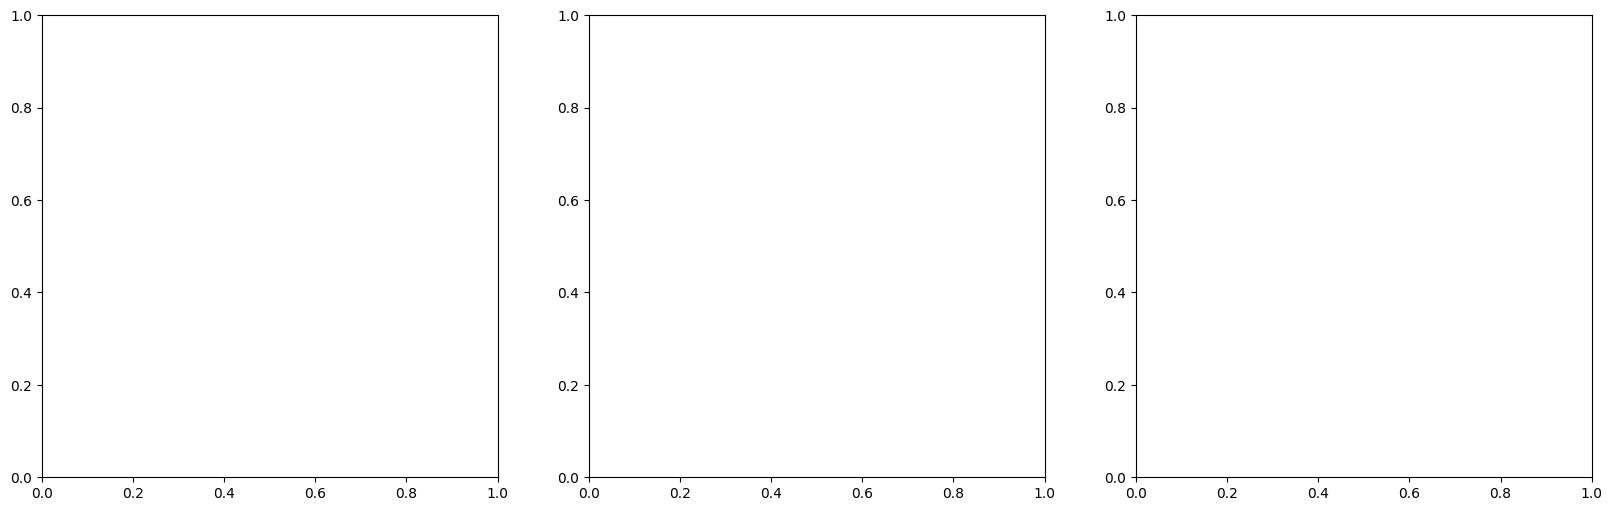

In [8]:
datetime_str = datetime.now().strftime("%Y%m%d_%H_h_%M_m")
device = 'cuda' if torch.cuda.is_available() else 'mps'

model_config_name = 'gin'

model = ModelFactory.create_model(
    model_config_name
)
train_config_name = 'default'
train_config = load_config("train", train_config_name)
optimizer_config_name = 'adam'
scheduler_config_name = 'step'

save_path = f"results/model_{model_config_name}_train_{train_config_name}_optim_{optimizer_config_name}_sch_{scheduler_config_name}/{datetime_str}"
os.makedirs(save_path, exist_ok=True)



trainer = Trainer(
    train_config=train_config,
    model=model,
    optimizer_config_name=optimizer_config_name,
    scheduler_config_name=scheduler_config_name,
    save_path=save_path,
    device=device,
)


trainer.fit(train_loader, valid_loader, epochs=EPOCHS, live_plot_step=10)
results = trainer.test(test_loader)

results = trainer.test(test_loader)

import json
with open(os.path.join(save_path, "results.json"), "w") as f:
    json.dump(results, f)
pd.DataFrame({'targets': results['targets'], 'predictions': results['predictions']}).to_csv(os.path.join(save_path, "predictions.csv"), index=False)
